In [93]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import Classic_NN.classic_nn
importlib.reload(Classic_NN.classic_nn)
from Classic_NN.classic_nn import ClassicNeuralNet

import Classic_NN.classic_trainer
importlib.reload(Classic_NN.classic_trainer)
from Classic_NN.classic_trainer import ClassicTrainer

import Genetic_NN.genetic_nn
importlib.reload(Genetic_NN.genetic_nn)

import Genetic_NN.genetic_trainer
importlib.reload(Genetic_NN.genetic_trainer)
from Genetic_NN.genetic_trainer import GeneticTrainer

import ACO_NN.aco_nn
importlib.reload(ACO_NN.aco_nn)

import ACO_NN.aco_trainer
importlib.reload(ACO_NN.aco_trainer)
from ACO_NN.aco_trainer import ACOTrainer

In [94]:
n = 1000
x1 = np.linspace(-np.pi, np.pi, n)
x2 = np.linspace(-np.pi, np.pi, n)
x3 = np.linspace(-np.pi, np.pi, n)
X = np.vstack((x1, x2, x3)).T
base = np.sin(x1) + np.cos(x2) - np.atan(x3)
y = (base).reshape(-1, 1)

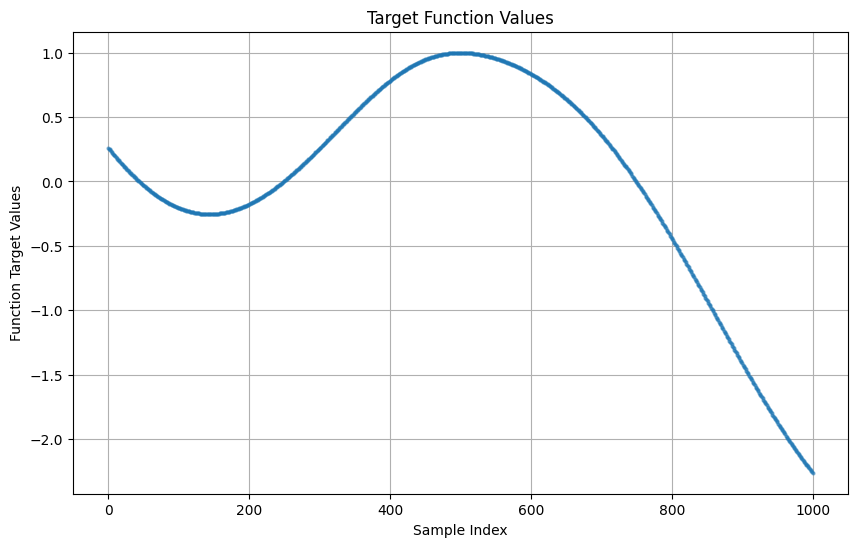

In [95]:
plt.figure(figsize=(10, 6))
plt.plot(y, 'o', markersize=2, alpha=0.5)
plt.title('Target Function Values')
plt.xlabel('Sample Index')
plt.ylabel('Function Target Values')
plt.grid()
plt.show()

In [98]:
np.random.seed(42)

# Hyperparam condivisi
input_size = 3
hidden_size =4
output_size = 1
soglia = 0.02
max_iter = 20000
print_every = 50

# Scegli qui come inizializzare i bias: 'zero' oppure 'random'
bias_init = 'random'

# Backprop
classic_model = ClassicNeuralNet(
    input_size,
    hidden_size,
    output_size,
    seed=42,
    bias_init=bias_init,
)
classic_trainer = ClassicTrainer(classic_model, learning_rate=0.01)
y_pred_bp, losses_bp = classic_trainer.train(
    X, y, print_every=print_every, soglia=soglia, max_iter=max_iter
)

# Genetic: confronto tra tutte le strategie
ga_strategies = ['sort', 'torneo', 'roulette', 'roulette_sus']
ga_results = {}

for strategy in ga_strategies:
    np.random.seed(42)
    ga_trainer = GeneticTrainer(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        population_size=16,
        mutation_rate=0.1,
        mutation_strength=0.1,
        bias_init=bias_init,
    )

    losses = ga_trainer.train(
        X,
        y,
        print_every=print_every,
        soglia=soglia,
        max_iter=max_iter,
        strategy=strategy,
        k_torneo=4,
    )

    best_idx = int(np.argmin([ind.loss(X, y) for ind in ga_trainer.population]))
    best_individual = ga_trainer.population[best_idx]
    y_pred = best_individual.forward(X)

    ga_results[strategy] = {
        'losses': losses.copy(),
        'y_pred': y_pred,
        'forward_calls': ga_trainer.forward_calls,
    }

# # ACO: training eseguito dopo GA

# aco_trainer = ACOTrainer(
#     input_size=input_size,
#     hidden_size=hidden_size,
#     output_size=output_size,
#     n_ants=16,
#     elite_fraction=0.25,
#     evaporation_rate=1.0,
#     pheromone_learning_rate=1.0,
#     init_sigma=1.0,
#     min_sigma=1e-3,
#     bias_init=bias_init,
#     seed=42,
#  )
# losses_aco = aco_trainer.train(
#     X,
#     y,
#     print_every=print_every,
#     soglia=soglia,
#     max_iter=max_iter,
#  )
# y_pred_aco = aco_trainer.best_individual.forward(X)

Iterazione 50, loss: 0.0918
Iterazione 100, loss: 0.0667
Iterazione 150, loss: 0.0508
Iterazione 200, loss: 0.0412
Iterazione 250, loss: 0.0359
Iterazione 300, loss: 0.0330
Iterazione 350, loss: 0.0314
Iterazione 400, loss: 0.0305
Iterazione 450, loss: 0.0299
Iterazione 500, loss: 0.0294
Iterazione 550, loss: 0.0291
Iterazione 600, loss: 0.0289
Iterazione 650, loss: 0.0287
Iterazione 700, loss: 0.0285
Iterazione 750, loss: 0.0284
Iterazione 800, loss: 0.0283
Iterazione 850, loss: 0.0282
Iterazione 900, loss: 0.0282
Iterazione 950, loss: 0.0281
Iterazione 1000, loss: 0.0281
Iterazione 1050, loss: 0.0280
Iterazione 1100, loss: 0.0280
Iterazione 1150, loss: 0.0280
Iterazione 1200, loss: 0.0279
Iterazione 1250, loss: 0.0279
Iterazione 1300, loss: 0.0279
Iterazione 1350, loss: 0.0279
Iterazione 1400, loss: 0.0279
Iterazione 1450, loss: 0.0278
Iterazione 1500, loss: 0.0278
Iterazione 1550, loss: 0.0278
Iterazione 1600, loss: 0.0278
Iterazione 1650, loss: 0.0278
Iterazione 1700, loss: 0.0278


In [99]:
print(f'Confronto finale con {hidden_size} nodi nel layer nascosto:')
bp_compute_units = classic_trainer.forward_calls + 2 * classic_trainer.backward_calls
print(
    f"Backprop -> iterazioni: {len(losses_bp)}, "
    f"loss finale: {losses_bp[-1]:.4f}, "
    f"forward_calls + 2 * backward_calls: {bp_compute_units}"
)

for strategy in ga_strategies:
    losses = ga_results[strategy]['losses']
    print(
        f"GA ({strategy}) -> evoluzioni: {len(losses)}, "
        f"loss finale: {losses[-1]:.4f}, "
        f"forward calls: {ga_results[strategy]['forward_calls']}"
    )

# print(
#     f"ACO -> evoluzioni: {len(losses_aco)}, "
#     f"loss finale: {losses_aco[-1]:.4f}, "
#     f"forward calls: {aco_trainer.forward_calls}"
# )

Confronto finale con 4 nodi nel layer nascosto:
Backprop -> iterazioni: 20000, loss finale: 0.0261, forward_calls + 2 * backward_calls: 60000
GA (sort) -> evoluzioni: 400, loss finale: 0.0192, forward calls: 6400
GA (torneo) -> evoluzioni: 155, loss finale: 0.0186, forward calls: 2480
GA (roulette) -> evoluzioni: 597, loss finale: 0.0200, forward calls: 9552
GA (roulette_sus) -> evoluzioni: 596, loss finale: 0.0198, forward calls: 9536


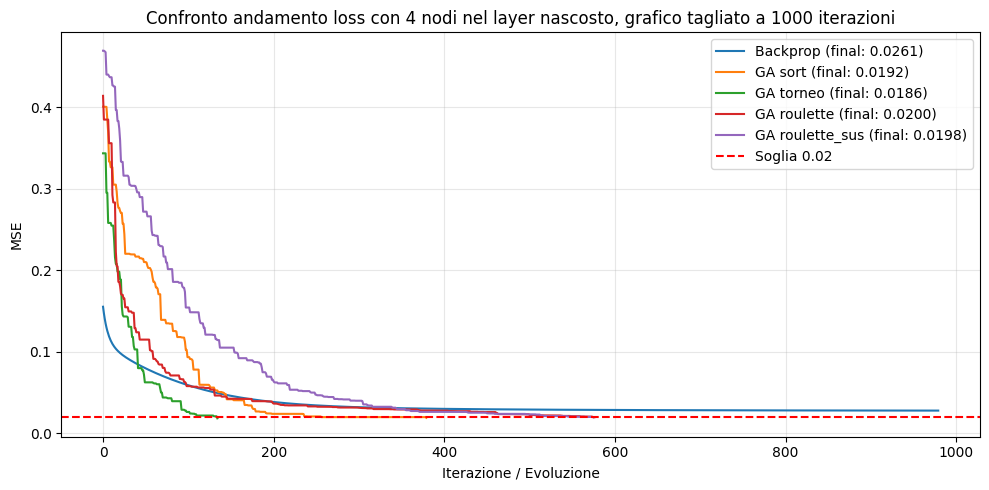

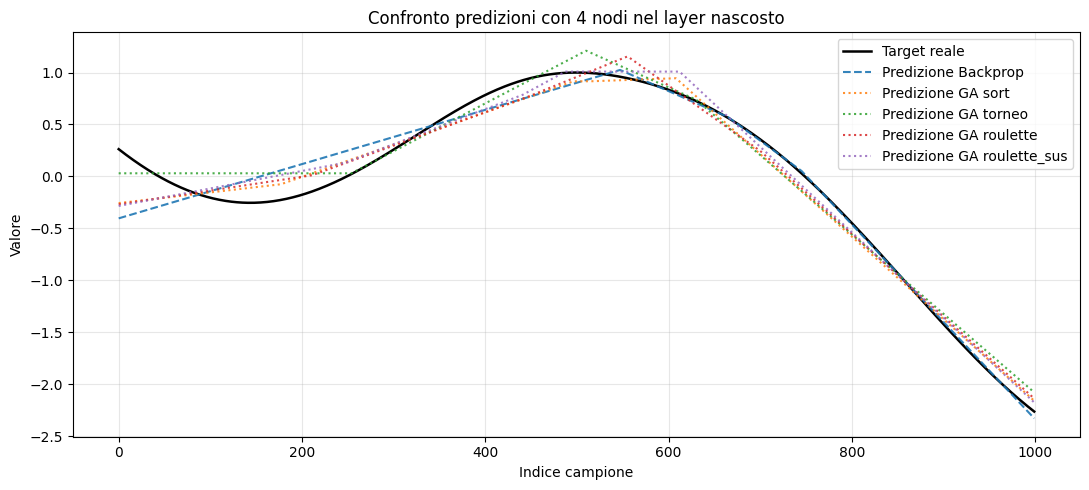

In [101]:
plt.figure(figsize=(10, 5))
plt.plot(losses_bp[20:1000], label=f"Backprop (final: {losses_bp[-1]:.4f})")
for strategy in ga_strategies:
    plt.plot(
        ga_results[strategy]['losses'][20:1000],
        label=f"GA {strategy} (final: {ga_results[strategy]['losses'][-1]:.4f})"
    )
#plt.plot(losses_aco[20:], label=f"ACO (final: {losses_aco[-1]:.4f})")
#ora voglio stampare una linea orizzontale che indichi la soglia di 0.02
plt.axhline(y=soglia, color='red', linestyle='--', label=f'Soglia {soglia}')
plt.xlabel('Iterazione / Evoluzione')
plt.ylabel('MSE')
plt.title(f'Confronto andamento loss con {hidden_size} nodi nel layer nascosto, grafico tagliato a 1000 iterazioni')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(y, label='Target reale', linewidth=1.8, color='black')
plt.plot(y_pred_bp, '--', label='Predizione Backprop', alpha=0.9)
for strategy in ga_strategies:
   plt.plot(
        ga_results[strategy]['y_pred'],
        ':',
        label=f'Predizione GA {strategy}',
        alpha=0.85
    )
# plt.plot(y_pred_aco, '-.', label='Predizione ACO', alpha=0.9)
plt.title(f'Confronto predizioni con {hidden_size} nodi nel layer nascosto')
plt.xlabel('Indice campione')
plt.ylabel('Valore')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import importlib
import experiments
importlib.reload(experiments)
from experiments import run_experiments

In [15]:
df = run_experiments(
    X=X,
    y=y,
    seeds=[42],
    hidden_sizes=[3, 4, 5],
    soglie=[0.05, 0.02],
    max_iter=20000,
    bias_init='random',
    learning_rate=0.01,
    population_sizes=[8, 16, 32],
    mutation_rate=0.1,
    mutation_strength=0.1,
    ga_strategies=['sort', 'torneo', 'roulette', 'roulette_sus'],
    elite_fraction=0.25,
    evaporation_rate=1.0,
    pheromone_learning_rate=1.0,
    ClassicNeuralNet=ClassicNeuralNet,
    ClassicTrainer=ClassicTrainer,
    GeneticTrainer=GeneticTrainer,
    ACOTrainer=ACOTrainer,
 )

In [16]:
import pandas as pd
pd.set_option("display.max_rows", None)
df

,method,strategy,seed,hidden_size,soglia,population_size,iterations,final_loss,compute_units,forward_calls,time,converged,learning_rate,mutation_rate,mutation_strength,n_ants,elite_fraction,evaporation_rate,pheromone_learning_rate
0,backprop,None,42,3,0.05,8,11036,0.049999,33108,11036,0.785862,True,0.01,NaN,NaN,NaN,NaN,NaN,NaN
1,GA,sort,42,3,0.05,8,226,0.045433,1808,1808,0.071789,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
2,GA,torneo,42,3,0.05,8,3747,0.049727,29976,29976,1.299029,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
3,GA,roulette,42,3,0.05,8,1084,0.049739,8672,8672,0.423523,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
4,GA,roulette_sus,42,3,0.05,8,601,0.047389,4808,4808,0.222879,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
5,ACO,None,42,3,0.05,8,370,0.049983,2960,2960,0.189257,True,NaN,NaN,NaN,8.0,0.25,1.0,1.0
6,backprop,None,42,3,0.05,16,11036,0.049999,33108,11036,0.849524,True,0.01,NaN,NaN,NaN,NaN,NaN,NaN
7,GA,sort,42,3,0.05,16,114,0.049752,1824,1824,0.072509,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
8,GA,torneo,42,3,0.05,16,54,0.047569,864,864,0.033239,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
9,GA,roulette,42,3,0.05,16,170,0.049993,2720,2720,0.134085,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN


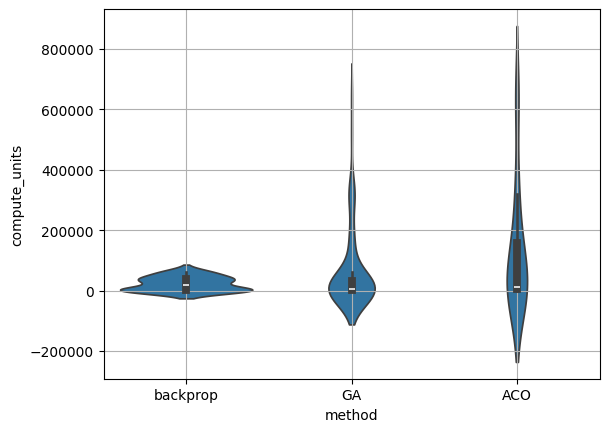

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=df, x="method", y="compute_units")
plt.grid()
plt.show()